
## - 23MS121 
## - Manish Behera

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
#Define methods, courtesy: Solving-ODEs, Prof. Rangeet Bhattacharyya
def euler(f1, x, y, h):
    return y + h * f1(x, y)

def midpoint(f1, x, y, h):
    k1 = h * f1(x, y)
    return y + h * f1(x + h / 2, y + k1 / 2)

def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller(my_method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64) # note y_ini is an array, can't pass just a number or a float
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = my_method(fn, x, y, h)
    return ys

### Q1 
(8 points) Consider the equation
dx
dt =−xt
(a) (4 points) Use Euler and Midpoint methods to solve the equations using h = 0.01 from tini = 0
to tfinal = 15. The given initial condition is x(0) = 1.0. Plot the solutions along with the exact
solution.
(b) (2 points) Now choose h = 10.0n for n = −4 to n = −2 in steps of 0.2. For each h, keep
tfinal fixed and solve the above equations using the two methods. For each h, for each method,
estimate the error of the position value of the final point (absolute deviation from the exact
solution).
(c) (2 points) Plot and fit log10h versus log10 of the error with a straight line to estimate the errors
of each of the method


Solve ODE $\frac{dx}{dt} = -xt$ with initial condition $x(0) = 1.0$ from $t=0$ to $t=15$ using step size $h=0.01$.

exact solution $x(t) = e^{-t^2/2}$.

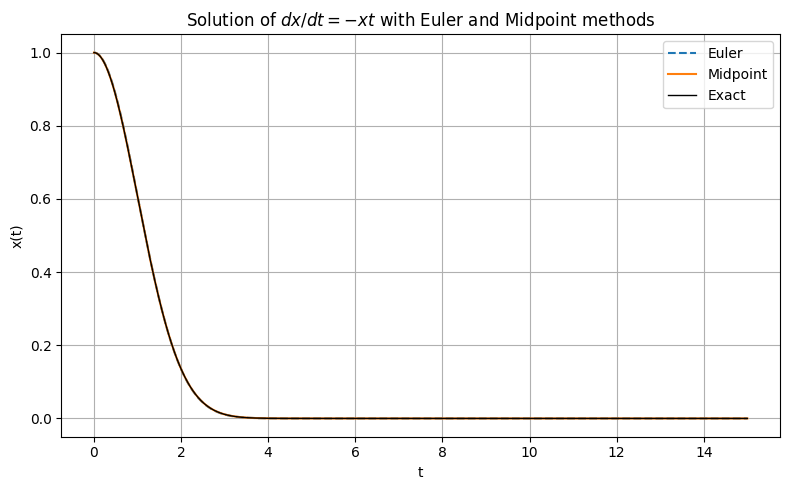

In [3]:
# (a) Euler and Midpoint methods for dx/dt = -xt
# Define the function for the ODE: dx/dt = -xt

def f(t, x):
    return -x * t

# Params
h = 0.01
tini = 0.0
tfinal = 15.0
N = int((tfinal - tini) / h) + 1
ts = np.linspace(tini, tfinal, N)


y_ini = np.array([1.0]) # x(0) = 1, pass an array as required in the caller function

xs_euler = caller(euler, f, y_ini, N, ts, h).flatten()
xs_mid = caller(midpoint, f, y_ini, N, ts, h).flatten()

# Exact soln is x(t) = exp(-t^2/2)
x_exact = np.exp(-ts**2 / 2)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(ts, xs_euler, label="Euler", linestyle="--")
plt.plot(ts, xs_mid, label="Midpoint", linestyle="-")
plt.plot(ts, x_exact, label="Exact", color="black", linewidth=1)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Solution of $dx/dt = -xt$ with Euler and Midpoint methods")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [5]:
# (b) Error analysis for Euler and Midpoint methods at different step sizes
n_vals = np.arange(-4, -2.01, 0.2)
hs = 10.0 ** n_vals

tini = 0.0
tfinal = 15.0
y_ini = np.array([1.0])

errors_euler = []
errors_mid = []

for h in hs:
    N = int((tfinal - tini) / h) + 1
    ts = np.linspace(tini, tfinal, N)
    x_exact = np.exp(-ts[-1]**2 / 2)
    # Euler
    xs_euler = caller(euler, f, y_ini, N, ts, h).flatten()
    err_euler = abs(xs_euler[-1] - x_exact)
    errors_euler.append(err_euler)
    # Midpoint
    xs_mid = caller(midpoint, f, y_ini, N, ts, h).flatten()
    err_mid = abs(xs_mid[-1] - x_exact)
    errors_mid.append(err_mid)

# Convert to numpy arrays
errors_euler = np.array(errors_euler)
print(errors_euler)
errors_mid = np.array(errors_mid)
print(errors_mid)

[7.49005080e-51 1.15959525e-50 1.80548173e-50 2.74582597e-50
 4.09363692e-50 5.87821441e-50 8.14698618e-50 1.04766573e-49
 1.24060964e-49 1.35070287e-49]
[2.88795125e-54 1.06449600e-52 3.79922577e-53 1.68719131e-52
 3.77071983e-52 1.33735521e-51 1.33510926e-51 3.49225673e-51
 8.41962010e-51 1.51598153e-50]


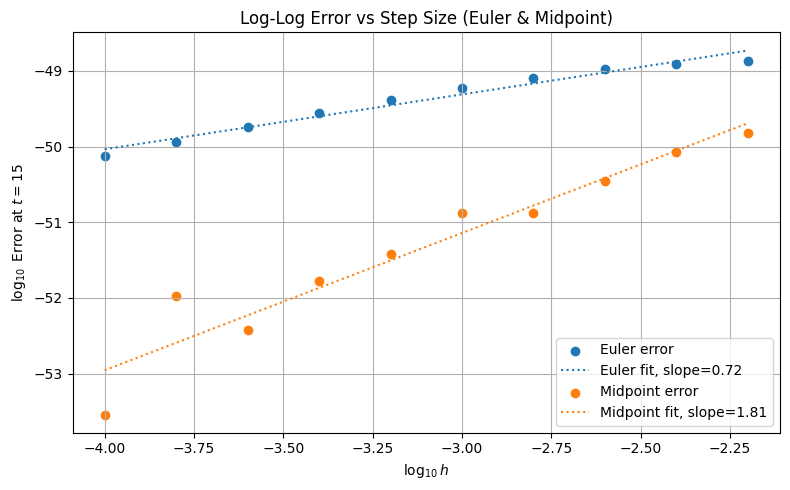

In [6]:
# (c) Log-Log plot and linear fit for error vs step size
from scipy.optimize import curve_fit

def linear(x, a, b):
    return a * x + b

log_hs = np.log10(hs)
log_err_euler = np.log10(errors_euler)
log_err_mid = np.log10(errors_mid)

# Fit lines
params_euler, _ = curve_fit(linear, log_hs, log_err_euler)
params_mid, _ = curve_fit(linear, log_hs, log_err_mid)

# Generate fit lines
xfit = np.linspace(log_hs[0], log_hs[-1], 200)
yfit_euler = linear(xfit, *params_euler)
yfit_mid = linear(xfit, *params_mid)

plt.figure(figsize=(8, 5))
plt.scatter(log_hs, log_err_euler, label="Euler error", color="tab:blue")
plt.plot(xfit, yfit_euler, color="tab:blue", linestyle=":", label=f"Euler fit, slope={params_euler[0]:.2f}")
plt.scatter(log_hs, log_err_mid, label="Midpoint error", color="tab:orange")
plt.plot(xfit, yfit_mid, color="tab:orange", linestyle=":", label=f"Midpoint fit, slope={params_mid[0]:.2f}")
plt.xlabel(r"$\log_{10} h$")
plt.ylabel(r"$\log_{10}$ Error at $t=15$")
plt.title("Log-Log Error vs Step Size (Euler & Midpoint)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Q2
(12 points) Two coupled first-order equations
dy
dt = p
dp
dt = −4π2y
define simple harmonic motion with period 1.
(a) (8 points) Use Euler and Midpoint methods to solve the equations using h = 0.01 from tini = 0
to tfinal = 15. The given initial condition is y(0) = 1.0 and p(0) = 0.0. Plot the solutions along
with the exact solution.
(b) (2 points) Now choose h = 10.0n for n = −4 to n = −2 in steps of 0.2. For each h, keep
tfinal fixed and solve the above equations using the two methods. For each h, for each method,
estimate the error of the position value of the final point (absolute deviation from the exact
solution).
(c) (2 points) Plot and fit log10h versus log10 of the error with a straight line to estimate the errors
of each of the method


The system:

$$
\frac{dy}{dt} = p \\
\frac{dp}{dt} = -4\pi^2 y
$$

inital conditions $y(0) = 1.0$, $p(0) = 0.0$. period 1.0.


solve the system from $t=0$ to $t=15$ with $h=0.01$ compare with the exact solution $y(t) = \cos(2\pi t)$, $p(t) = -2\pi \sin(2\pi t)$.

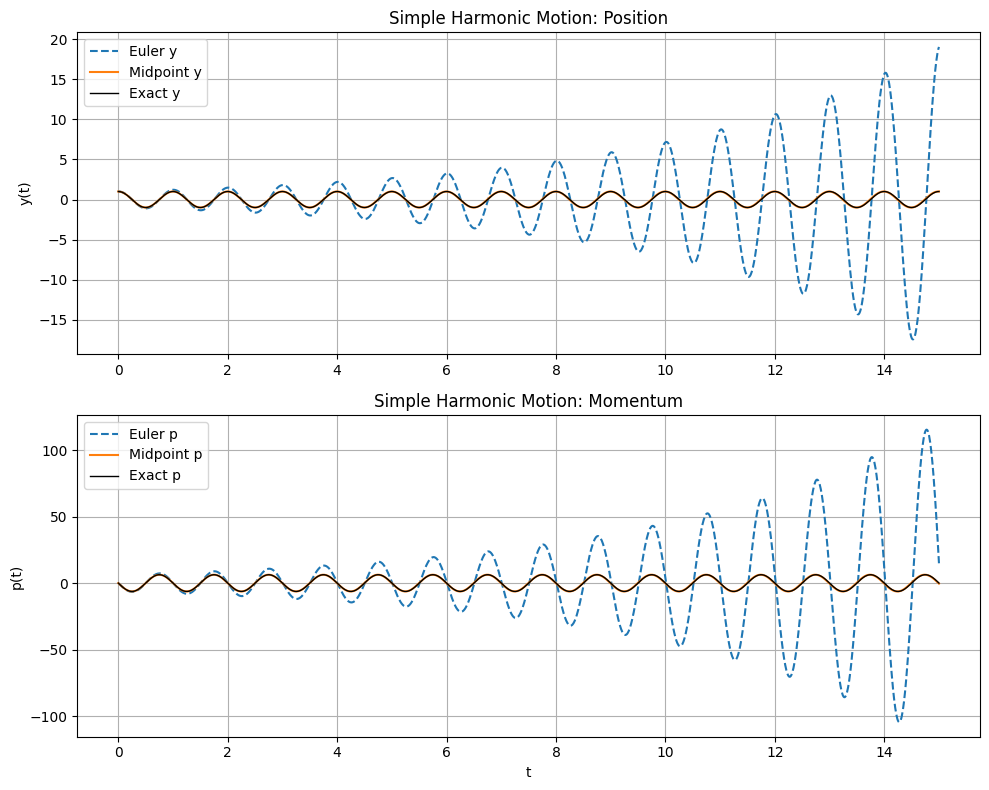

In [7]:
# (a) Euler and Midpoint methods for coupled SHM equations
def shm_system(t, Y):
    return np.array([Y[1], -4 * np.pi**2 * Y[0]])

h = 0.01
tini = 0.0
tfinal = 15.0
N = int((tfinal - tini) / h) + 1
ts = np.linspace(tini, tfinal, N)

Y0 = np.array([1.0, 0.0])

# Euler and Midpoint solutions
ys_euler = caller(euler, shm_system, Y0, N, ts, h)
ys_mid = caller(midpoint, shm_system, Y0, N, ts, h)

# Exact solutions
y_exact = np.cos(2 * np.pi * ts)
p_exact = -2 * np.pi * np.sin(2 * np.pi * ts)

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(ts, ys_euler[:, 0], label="Euler y", linestyle="--")
plt.plot(ts, ys_mid[:, 0], label="Midpoint y", linestyle="-")
plt.plot(ts, y_exact, label="Exact y", color="black", linewidth=1)
plt.ylabel("y(t)")
plt.title("Simple Harmonic Motion: Position")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(ts, ys_euler[:, 1], label="Euler p", linestyle="--")
plt.plot(ts, ys_mid[:, 1], label="Midpoint p", linestyle="-")
plt.plot(ts, p_exact, label="Exact p", color="black", linewidth=1)
plt.xlabel("t")
plt.ylabel("p(t)")
plt.title("Simple Harmonic Motion: Momentum")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [8]:
# (b) Error analysis for Euler and Midpoint methods at different step sizes (SHM)
n_vals = np.arange(-4, -2.01, 0.2)
hs = 10.0 ** n_vals

tini = 0.0
tfinal = 15.0
Y0 = np.array([1.0, 0.0])

errors_euler = []
errors_mid = []

for h in hs:
    N = int((tfinal - tini) / h) + 1
    ts = np.linspace(tini, tfinal, N)
    y_exact = np.cos(2 * np.pi * ts[-1])
    # Euler
    ys_euler = caller(euler, shm_system, Y0, N, ts, h)
    err_euler = abs(ys_euler[-1, 0] - y_exact)
    errors_euler.append(err_euler)
    # Midpoint
    ys_mid = caller(midpoint, shm_system, Y0, N, ts, h)
    err_mid = abs(ys_mid[-1, 0] - y_exact)
    errors_mid.append(err_mid)

errors_euler = np.array(errors_euler)
print(errors_euler)
errors_mid = np.array(errors_mid)
print(errors_mid)


[0.03005151 0.04804475 0.07720936 0.1251013  0.20540094 0.3445162
 0.59872188 1.10311564 2.24561157 5.45260369]
[2.90302893e-09 1.58648487e-07 4.31017995e-08 2.25416116e-08
 1.51113194e-07 1.31133205e-05 9.57489825e-06 3.01972929e-05
 1.24634806e-04 6.71420283e-04]


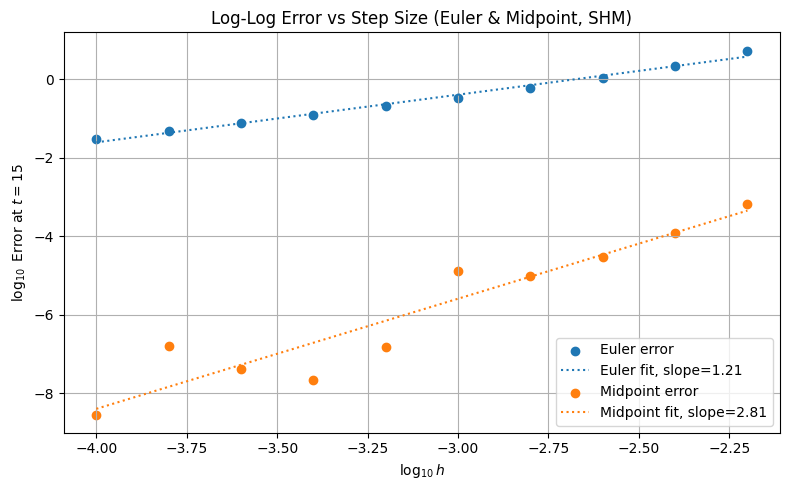

In [9]:
# (c) Log-Log plot and linear fit for error vs step size (SHM)
from scipy.optimize import curve_fit

def linear(x, a, b):
    return a * x + b

log_hs = np.log10(hs)
log_err_euler = np.log10(errors_euler)
log_err_mid = np.log10(errors_mid)

# Fit lines
params_euler, _ = curve_fit(linear, log_hs, log_err_euler)
params_mid, _ = curve_fit(linear, log_hs, log_err_mid)

xfit = np.linspace(log_hs[0], log_hs[-1], 200)
yfit_euler = linear(xfit, *params_euler)
yfit_mid = linear(xfit, *params_mid)

plt.figure(figsize=(8, 5))
plt.scatter(log_hs, log_err_euler, label="Euler error", color="tab:blue")
plt.plot(xfit, yfit_euler, color="tab:blue", linestyle=":", label=f"Euler fit, slope={params_euler[0]:.2f}")
plt.scatter(log_hs, log_err_mid, label="Midpoint error", color="tab:orange")
plt.plot(xfit, yfit_mid, color="tab:orange", linestyle=":", label=f"Midpoint fit, slope={params_mid[0]:.2f}")
plt.xlabel(r"$\log_{10} h$")
plt.ylabel(r"$\log_{10}$ Error at $t=15$")
plt.title("Log-Log Error vs Step Size (Euler & Midpoint, SHM)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

note euler method is not symplectic and bad; midpoint is stable 